<a href="https://colab.research.google.com/github/ridhimapandey117/Python-Course-YT/blob/master/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#will need to do plt.show() to show graph

In [ ]:
from google.colab import files
uploaded = files.upload()
import io
import pandas as pd
for filename, filecontent in uploaded.items():
  print(f'Uploaded file: {filename}, size: {len(filecontent)} bytes')
  if filename.endswith('.csv'):
    df = pd.read_csv(io.BytesIO(filecontent))
print(df.head())

Saving USA_Housing.csv to USA_Housing.csv
Uploaded file: USA_Housing.csv, size: 726209 bytes
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 67

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
df.info() #informs you of the total number of columns, entries, etc

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [ ]:
df.describe() #gives you statistical info about data i.e. mean, max, min

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


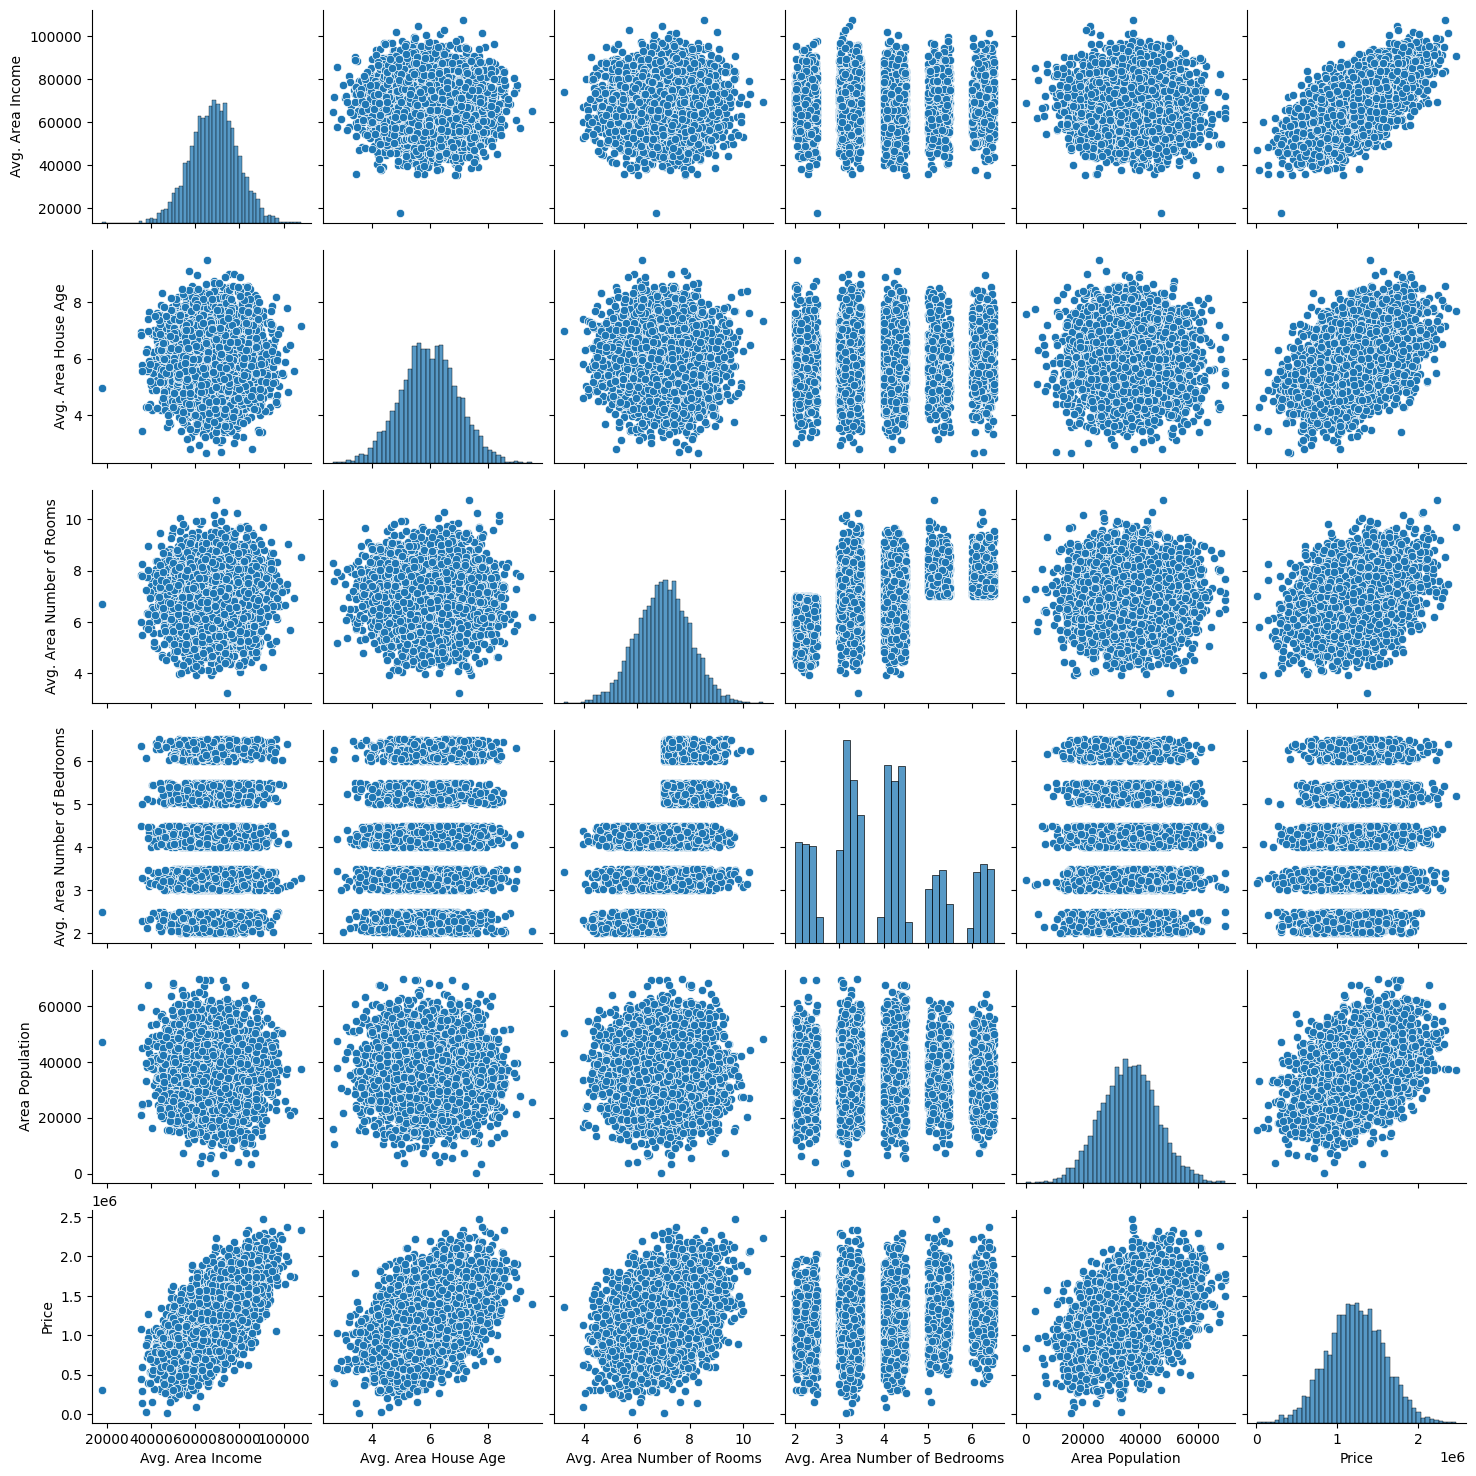

In [ ]:
sns.pairplot(df)

/tmp/ipykernel_638/834922981.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price'])


<Axes: xlabel='Price', ylabel='Density'>

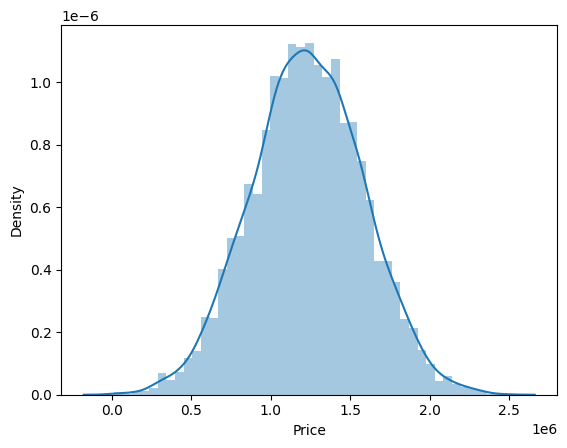

In [ ]:
sns.distplot(df['Price'])

In [ ]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [ ]:
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price']]
y = df['Price']
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.4,random_state=101)
'''
- Using tuple unpacking to grab the training set and testing set
- It'll go through ur xtrain and ytrain data and then both the test data
- test_size is optional, that's the percentage of data u want to be allocated to that test size
- random split is just whatever...
'''

"\n- Using tuple unpacking to grab the training set and testing set\n- It'll go through ur xtrain and ytrain data and then both the test data\n- test_size is optional, that's the percentage of data u want to be allocated to that test size\n- random split is just whatever...\n"

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lm = LinearRegression() #creating a linear regression object

In [ ]:
lm.fit(x_train, y_train)

LinearRegression()

In [ ]:
print(lm.intercept_) #prints out intercept

-2.3283064365386963e-10


In [ ]:
lm.coef_
#Each of these coefficents correspond to the columns in x_train

array([ 3.91841338e-15, -1.30517819e-12, -6.14076509e-12, -3.48921454e-12,
       -8.23993651e-16,  1.00000000e+00])

In [ ]:
#Coefficents
# A unit increase in one of the columns is equal to an increase of [coeff]

cdf = pd.DataFrame(lm.coef_, X.columns,columns=['Coeff'])
cdf

,Coeff
Avg. Area Income,3.918413e-15
Avg. Area House Age,-1.305178e-12
Avg. Area Number of Rooms,-6.140765e-12
Avg. Area Number of Bedrooms,-3.489215e-12
Area Population,-8.239937e-16
Price,1.000000e+00


#Predictions

In [ ]:
predictions = lm.predict(x_test)
predictions

array([1251688.61570287,  873048.31964236, 1696977.6628326 , ...,
        151527.08262655, 1343824.21514432, 1906024.63648502])

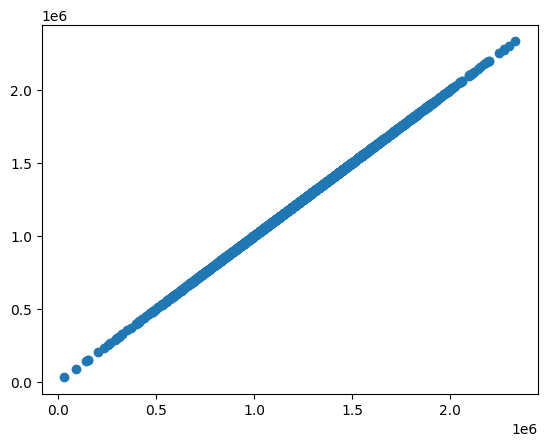

In [ ]:
plt.scatter(y_test, predictions)
#means that the x_test predictions turned out to be mostly right compared to the actual prices in y_test

/tmp/ipykernel_638/2744528648.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - predictions))


<Axes: xlabel='Price', ylabel='Density'>

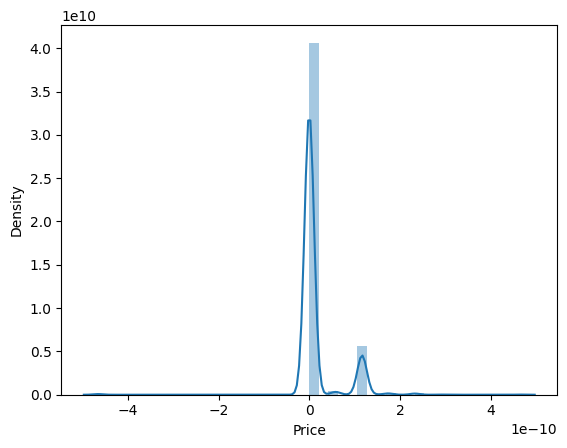

In [ ]:
sns.distplot((y_test - predictions))
#this is a histogram of the reisduals (or leftovers) of the data
#If data doesn't look right, look back on data to see if linear regression was the right choice

#Regression Evaluation Metrics

Mean Absolute Error (MAE)
  
  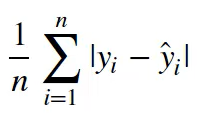

Mean Squared Error (MSE)

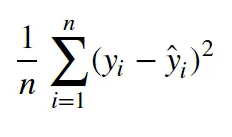

Root Mean Squared Error (RMSE)

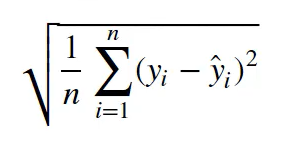

In [ ]:
from sklearn import metrics
metrics.mean_absolute_error(y_test, predictions)

1.737134880386293e-11

In [ ]:
metrics.mean_squared_error(y_test, predictions)

2.5610305858029788e-21

In [ ]:
metrics.root_mean_squared_error(y_test, predictions)

5.060662590810593e-11

#Practice

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import files
uploaded = files.upload()
import io
import pandas as pd
for filename, filecontent in uploaded.items():
  print(f'Uploaded file: {filename}, size: {len(filecontent)} bytes')
  if filename.endswith('.csv'):
    ad_data = pd.read_csv(io.BytesIO(filecontent))
print(ad_data.head())

Saving advertising.csv to advertising (1).csv
Uploaded file: advertising (1).csv, size: 107424 bytes
   Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                     68.95   35     61833.90                256.09   
1                     80.23   31     68441.85                193.77   
2                     69.47   26     59785.94                236.50   
3                     74.15   29     54806.18                245.89   
4                     68.37   35     73889.99                225.58   

                           Ad Topic Line            City  Male     Country  \
0     Cloned 5thgeneration orchestration     Wrightburgh     0     Tunisia   
1     Monitored national standardization       West Jodi     1       Nauru   
2       Organic bottom-line service-desk        Davidton     0  San Marino   
3  Triple-buffered reciprocal time-frame  West Terrifurt     1       Italy   
4          Robust logistical utilization    South Manuel     0     Iceland   

   

In [ ]:
ad_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [ ]:
ad_data.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


<Axes: xlabel='Age', ylabel='Count'>

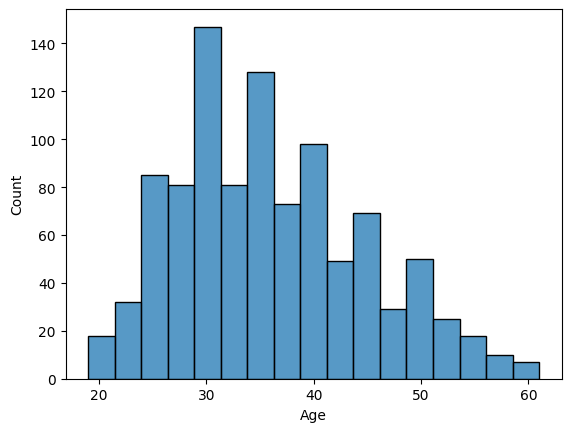

In [ ]:
sns.histplot(ad_data['Age'])

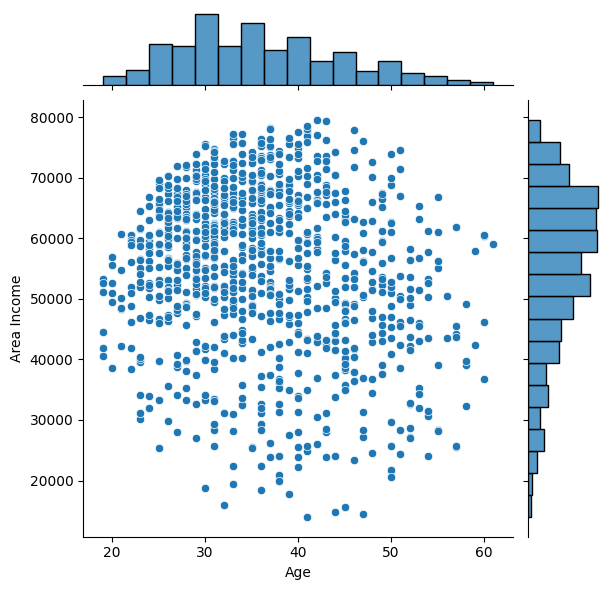

In [ ]:
sns.jointplot(y='Area Income', x='Age', data=ad_data)

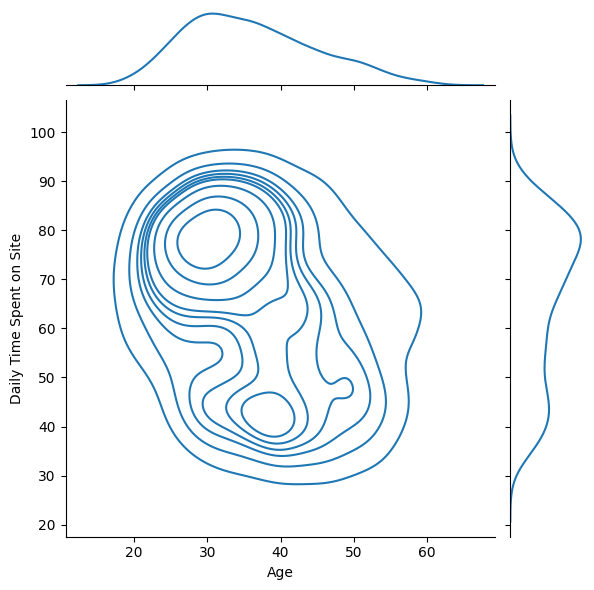

In [ ]:
sns.jointplot(x='Age', y='Daily Time Spent on Site', data=ad_data, kind='kde')

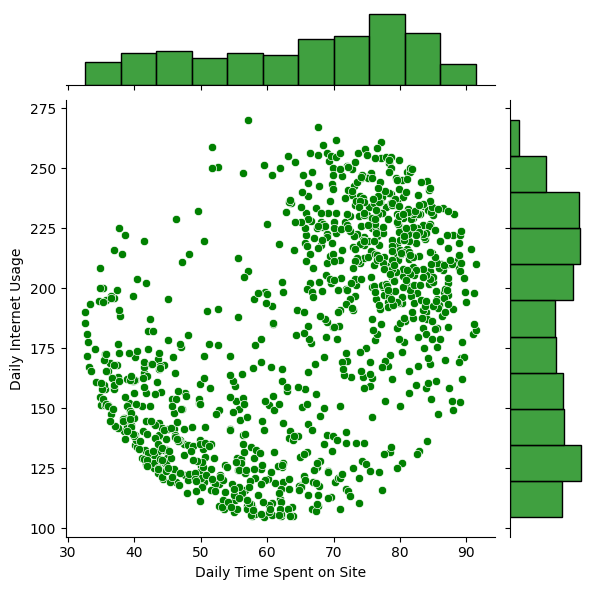

In [ ]:
sns.jointplot(x='Daily Time Spent on Site', y='Daily Internet Usage', data=ad_data,color='green')

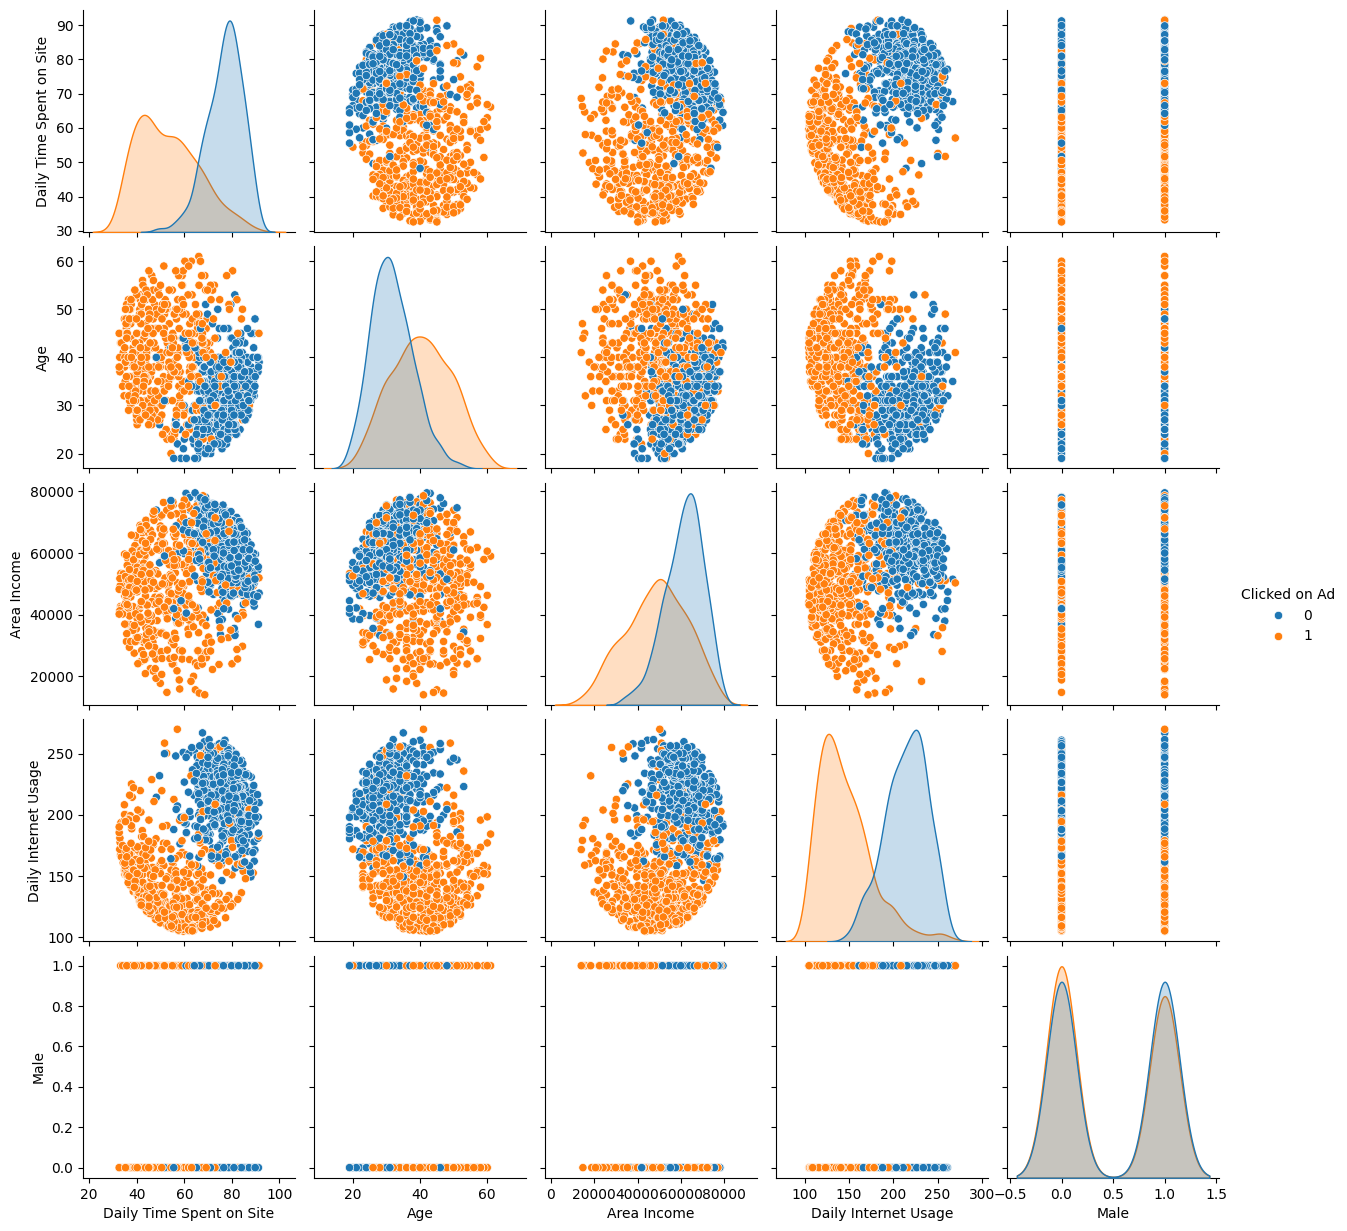

In [ ]:
sns.pairplot(ad_data, hue = 'Clicked on Ad')

In [ ]:
ad_data.columns

Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad'],
      dtype='object')

In [ ]:
x = ad_data[['Daily Time Spent on Site', 'Area Income', 'Daily Internet Usage', 'Male', 'Clicked on Ad']]
y = ad_data['Age']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.35)

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

model = LogisticRegression()
model.fit(x_train, y_train)

predictions = model.predict(x_test)
predictions

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([36, 36, 31, 29, 31, 31, 31, 31, 31, 31, 36, 29, 31, 31, 31, 31, 31,
       31, 36, 31, 31, 31, 36, 36, 36, 31, 31, 31, 31, 36, 31, 31, 31, 42,
       36, 31, 31, 31, 36, 42, 31, 31, 36, 36, 36, 42, 31, 31, 36, 36, 36,
       42, 31, 27, 31, 36, 31, 31, 31, 31, 36, 31, 31, 31, 36, 36, 31, 31,
       42, 31, 42, 31, 31, 31, 31, 29, 31, 31, 31, 31, 36, 42, 31, 36, 29,
       31, 31, 36, 36, 31, 42, 31, 36, 42, 31, 36, 31, 36, 31, 36, 29, 31,
       42, 31, 31, 31, 29, 36, 31, 31, 36, 31, 36, 31, 31, 42, 31, 36, 31,
       42, 42, 31, 31, 36, 31, 42, 36, 31, 31, 31, 31, 31, 31, 36, 31, 36,
       36, 31, 31, 31, 36, 31, 36, 31, 36, 31, 31, 36, 36, 42, 31, 34, 31,
       31, 29, 31, 31, 31, 36, 31, 31, 31, 36, 36, 29, 31, 36, 31, 36, 31,
       42, 42, 31, 31, 31, 31, 36, 36, 42, 36, 31, 31, 31, 36, 31, 31, 31,
       31, 31, 31, 36, 31, 36, 42, 31, 36, 31, 31, 31, 36, 31, 42, 31, 42,
       42, 31, 31, 36, 36, 31, 31, 36, 31, 36, 31, 31, 42, 36, 31, 36, 31,
       36, 31, 42, 31, 31

In [ ]:
from sklearn.metrics import classification_report
report = classification_report(y_test, predictions)
print(report)

              precision    recall  f1-score   support

          20       0.00      0.00      0.00         4
          21       0.00      0.00      0.00         3
          22       0.00      0.00      0.00         2
          23       0.00      0.00      0.00         6
          24       0.00      0.00      0.00         9
          25       0.00      0.00      0.00        15
          26       0.00      0.00      0.00        10
          27       0.00      0.00      0.00        13
          28       0.00      0.00      0.00        18
          29       0.00      0.00      0.00        15
          30       0.00      0.00      0.00        16
          31       0.07      0.70      0.13        20
          32       0.00      0.00      0.00         9
          33       0.00      0.00      0.00        16
          34       0.00      0.00      0.00        12
          35       0.00      0.00      0.00        13
          36       0.03      0.20      0.05        15
          37       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
